In [2]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def load_writer_pickle(pickle_root, writer_id):
    path = os.path.join(pickle_root, f"{writer_id}.pkl")
    with open(path, "rb") as f:
        return pickle.load(f)

def show_glyph_candidates(samples, char, connection_type, max_samples=16, img_size=(64,64)):

    filtered = [s for s in samples if s.get('connection') == connection_type and s.get('image') is not None]
    if not filtered:
        print(f"No samples for char '{char}' type '{connection_type}'")
        return
    n = len(filtered)
    ncols = min(n, 8)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*2, nrows*2))
    axes = axes.flatten() if n > 1 else [axes]
    for i, sample in enumerate(filtered):
        img = sample['image']
        if img.ndim == 2:
            img = np.stack([img]*3, axis=-1)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"idx={i}")
        axes[i].axis('off')
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    plt.suptitle(f"{char} [{connection_type}] ({n} candidates)")
    plt.show()


def show_writer_all_chars_grid(pickle_root, writer_id, connection_type='isolated', chars=None):

    writer_data = load_writer_pickle(pickle_root, writer_id)
    if chars is None:
        chars = sorted(writer_data.keys())
    for char in chars:
        samples = writer_data[char]
        show_glyph_candidates(samples, char, connection_type)


In [2]:
def rdp(points, eps):
    if len(points) < 3:
        return points

    a, b = points[0], points[-1]
    ab = b - a
    ab_len2 = (ab**2).sum()
    if ab_len2 == 0:
        dists = np.linalg.norm(points - a, axis=1)
    else:
        t = ((points - a) @ ab) / ab_len2
        proj = a + np.outer(np.clip(t, 0, 1), ab)
        dists = np.linalg.norm(points - proj, axis=1)

    idx = np.argmax(dists)
    dmax = dists[idx]
    if dmax > eps:
        left  = rdp(points[:idx+1], eps)
        right = rdp(points[idx:], eps)
        return np.vstack([left[:-1], right])
    else:
        return np.vstack([a, b])


def _extract_xy(sample):
    traj = sample.get('trajectory', None)
    if traj is None: return None
    arr = np.asarray(traj, dtype=np.float32)
    if arr.ndim != 2 or arr.shape[0] < 2 or arr.shape[1] < 2: return None
    xy = arr[:, :2]
    nz = np.where(np.abs(xy).sum(axis=1) > 0)[0]
    if len(nz) == 0: return None
    return xy[:nz[-1] + 1]

def _resample_arclen(xy, M=64, eps=1e-6):
    d = np.sqrt(((np.diff(xy, axis=0))**2).sum(axis=1))
    s = np.hstack([0.0, np.cumsum(d)])
    L = s[-1]
    if L < eps:
        return np.repeat(xy[:1], M, axis=0)
    t = np.linspace(0.0, L, M)
    x = np.interp(t, s, xy[:,0])
    y = np.interp(t, s, xy[:,1])
    return np.stack([x,y], axis=1)

def _normalize_xy(xy, center="centroid", scale="path", eps=1e-6):
    xy = xy.copy()
    if center == "start":
        xy -= xy[0]
    else:
        xy -= xy.mean(axis=0, keepdims=True)
    if scale == "path":
        L = np.sqrt(((np.diff(xy, axis=0))**2).sum(axis=1)).sum()
        s = max(L, eps)
    else:
        s = max(xy[:,0].max()-xy[:,0].min(), xy[:,1].max()-xy[:,1].min(), eps)
    xy /= s
    return xy


def select_and_show_representative(
    samples,
    char='?',
    connection_type='isolated',
    max_cols=8,
    M=64,
    use_rdp=True, rdp_eps=1.5,
    center='centroid', scale='path',
    highlight_color='red'
):

    proc = []
    vis  = []
    for i, s in enumerate(samples):
        if s.get('connection') != connection_type:
            continue
        if s.get('image') is None:
            continue
        xy = _extract_xy(s)
        if xy is None or xy.shape[0] < 5:
            continue
        if use_rdp:
            xy = rdp(xy, rdp_eps)
            if xy.shape[0] < 2:
                continue
        xy = _resample_arclen(xy, M=M)
        xy = _normalize_xy(xy, center=center, scale=scale)
        proc.append((i, xy))
        vis.append((i, s['image']))

    if not proc:
        print(f"[select] No candidates for '{char}' / type='{connection_type}'")
        return None, None


    stack = np.stack([p[1] for p in proc], axis=0)
    A = stack[:, None, :, :] - stack[None, :, :, :]
    D = np.sqrt((A**2).sum(axis=(2,3)))
    j = int(np.argmin(D.mean(axis=1)))
    best_orig_idx = proc[j][0]


    n = len(vis)
    ncols = min(n, max_cols)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*2, nrows*2))
    axes = axes.flatten() if n > 1 else [axes]
    for k, (orig_idx, img) in enumerate(vis):
        ax = axes[k]
        if img.ndim == 2:
            ax.imshow(np.stack([img]*3, axis=-1), cmap='gray')
        else:
            ax.imshow(img, cmap='gray')
        title = f"idx={orig_idx}"
        if orig_idx == best_orig_idx:
            title += "  [REP]"

            ax.add_patch(Rectangle((0,0), 1, 1, transform=ax.transAxes,
                                   fill=False, linewidth=2.5, edgecolor=highlight_color))
        ax.set_title(title, fontsize=9)
        ax.axis('off')
    for t in range(k+1, len(axes)):
        axes[t].axis('off')
    plt.suptitle(f"{char} [{connection_type}] ({n} candidates)")
    plt.tight_layout()
    plt.show()

    return best_orig_idx, fig


In [3]:
p = "../../dataset/eng/sent_pickles/0_sent.pkl"
mp = pickle.load(open(p, "rb"))
sid = next(iter(mp))
trajs = mp[sid]["trajs"]
pm   = [t[:,2].sum() for t in trajs if t.size>0]
eos  = [t[:,3].sum() for t in trajs if t.size>0]
eoc  = [t[:,4].sum() for t in trajs if t.size>0]
print("pen_move sum:", pm[:5], "EOS sum:", eos[:5], "EOC sum:", eoc[:5])


KeyError: 'trajs'

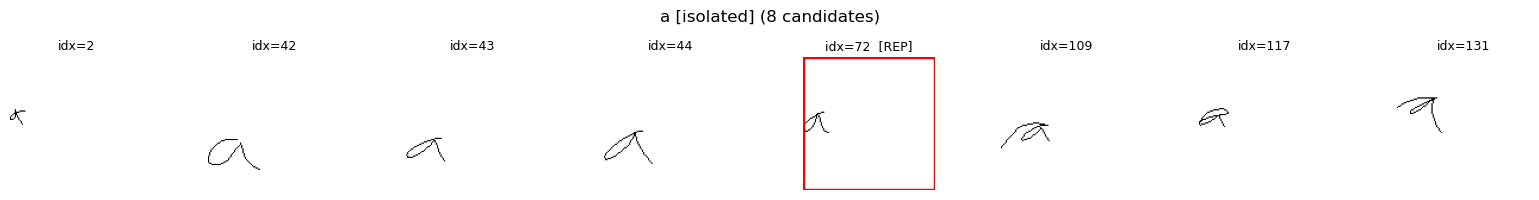

대표 샘플 index: 72


In [11]:
pickle_root = "../../dataset/eng/char_pickles"
writer_id = "0"
pickle_root = "../../dataset/eng/char_pickles"
writer_id = "0"

writer_data = load_writer_pickle(pickle_root, writer_id=writer_id)
samples = writer_data['a']
best_idx, _ = select_and_show_representative(
    samples, char='a', connection_type='isolated',
    M=64, use_rdp=True, rdp_eps=1.5, center='centroid', scale='path',
    highlight_color='red'
)
print("대표 샘플 index:", best_idx)
